In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [6]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 276kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.36MB/s]


In [7]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [10]:
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [11]:
num_epochs = 5
train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    acc = evaluate(model, test_loader, device)

    train_losses.append(loss)
    test_accuracies.append(acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f} | Test Acc: {acc:.4f}")

Epoch 1/5 | Loss: 0.3442 | Test Acc: 0.9447
Epoch 2/5 | Loss: 0.1574 | Test Acc: 0.9604
Epoch 3/5 | Loss: 0.1097 | Test Acc: 0.9705
Epoch 4/5 | Loss: 0.0827 | Test Acc: 0.9734
Epoch 5/5 | Loss: 0.0653 | Test Acc: 0.9744


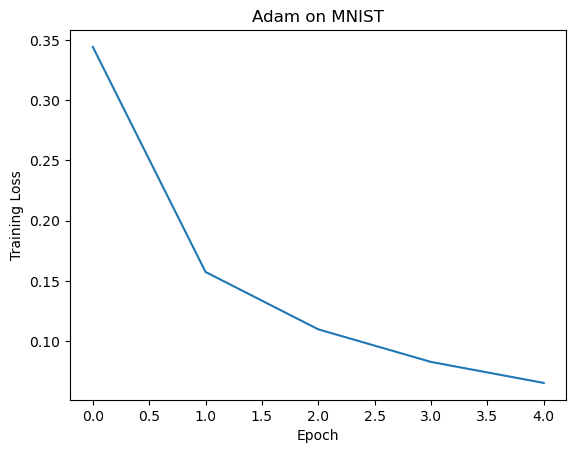

In [12]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Adam on MNIST")
plt.show()